=== Dataset Summary ===
Class 'bird': 22 images
Class 'drone': 26 images

=== Imbalance Analysis ===
Majority Class: 'drone' | Minority Class: 'bird'
Imbalance Ratio: 1.18x
✅ Dataset is relatively well-balanced.

Generating sample visualization plot...


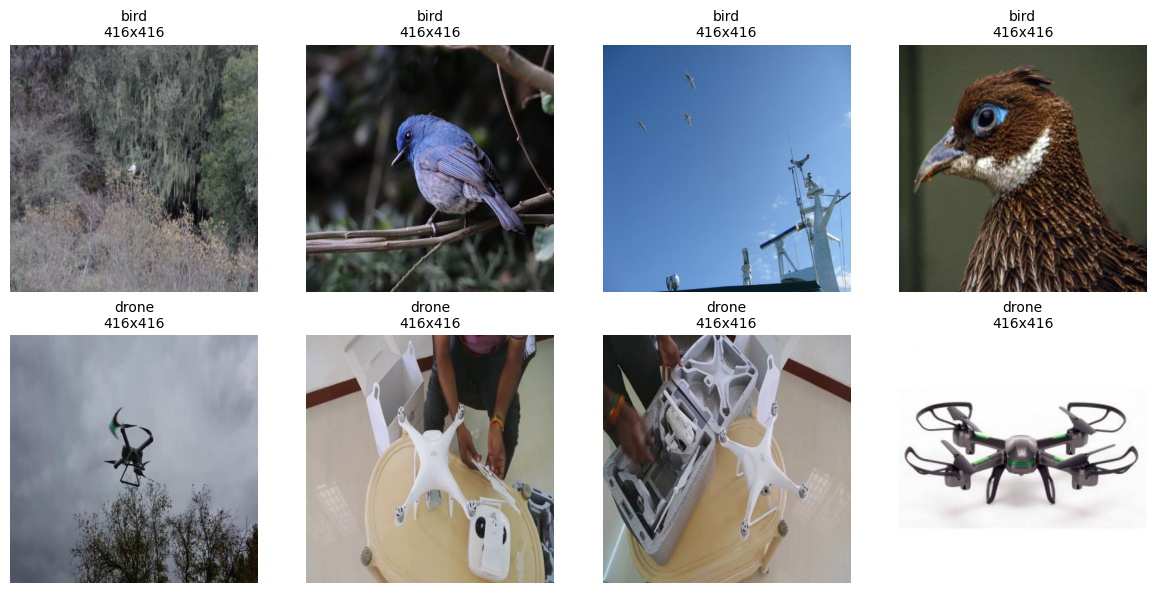

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define Dataset Path (Update this to your actual directory)
DATASET_DIR = "classification_dataset/train"  # Expects subfolders: 'bird' and 'drone'

# 2. Inspect Structure and Count Images
print("=== Dataset Summary ===")
class_counts = {}
if not os.path.exists(DATASET_DIR):
    print(f"Directory '{DATASET_DIR}' not found. Please verify your path.")
else:
    classes = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    
    for cls in classes:
        cls_path = os.path.join(DATASET_DIR, cls)
        # Filter for common image extensions
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        class_counts[cls] = len(images)
        print(f"Class '{cls}': {len(images)} images")

    # 3. Identify Class Imbalance
    if class_counts:
        max_class = max(class_counts, key=class_counts.get)
        min_class = min(class_counts, key=class_counts.get)
        ratio = class_counts[max_class] / max_class_value if (max_class_value := class_counts[min_class]) > 0 else 0
        
        print("\n=== Imbalance Analysis ===")
        print(f"Majority Class: '{max_class}' | Minority Class: '{min_class}'")
        print(f"Imbalance Ratio: {ratio:.2f}x")
        if ratio > 1.5:
            print("⚠️ Warning: Significant class imbalance detected. Consider data augmentation or class weighting.")
        else:
            print("✅ Dataset is relatively well-balanced.")

    # 4. Visualize Sample Images
    print("\nGenerating sample visualization plot...")
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    
    for row, cls in enumerate(classes[:2]):  # Loop through up to 2 classes (bird, drone)
        cls_path = os.path.join(DATASET_DIR, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        # Select 4 random samples
        samples = random.sample(images, min(4, len(images)))
        
        for col, img_name in enumerate(samples):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            
            ax = axes[row, col]
            ax.imshow(img)
            ax.set_title(f"{cls}\n{img.size[0]}x{img.size[1]}", fontsize=10)
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

In [2]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Configuration parameters
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Standard ImageNet distribution stats required for PyTorch pre-trained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define transformations per operational split
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),               # Resize slightly larger before cropping
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)), # 3. Zoom & Cropping
        transforms.RandomRotation(degrees=20),       # 3. Rotation
        transforms.RandomHorizontalFlip(p=0.5),      # 3. Horizontal Flipping
        transforms.RandomVerticalFlip(p=0.2),        # 3. Vertical Flipping
        transforms.ColorJitter(brightness=0.2),      # 3. Brightness adjustment
        transforms.ToTensor(),                       # 1. Normalizes pixel values to [0, 1]
        transforms.Normalize(IMAGENET_MEAN,          # 2. PyTorch model-specific normalization
                             IMAGENET_STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 2. Resizing to fixed size
        transforms.ToTensor(),                       # 1. Normalizes pixel values to [0, 1]
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
}

def get_pytorch_loaders(data_dir):
    """
    Creates PyTorch data loaders assuming directory structure:
    data_dir/train/bird/, data_dir/train/drone/, etc.
    """
    image_datasets = {
        x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
        for x in ['train', 'val'] if os.path.exists(os.path.join(data_dir, x))
    }
    
    dataloaders = {
        x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, 
                      shuffle=(x == 'train'), num_workers=4, pin_memory=True)
        for x in image_datasets.keys()
    }
    
    return dataloaders

In [3]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import preprocess_input

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 3. Data Augmentation block via Keras Layer Architecture
# Standard normalization [0, 1] can be done with layers.Rescaling(1./255), 
# but preprocess_input handles ImageNet scaling rules automatically.
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.055),           # ~20 degrees rotation
    layers.RandomFlip("horizontal_and_vertical"), # 3. Flipping
    layers.RandomZoom(height_factor=(-0.2, 0.0),   # 3. Zooming / Cropping simulation
                      width_factor=(-0.2, 0.0)),
    layers.RandomBrightness(factor=0.2)           # 3. Brightness adjustment
])

def load_and_preprocess_tf(data_dir):
    """
    Loads and structures image categories from local source paths.
    """
    # 2. Auto-resizes target assets to 224x224 fixed size
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/train",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/val",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    
    # Apply Augmentations strictly on Training split
    train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                            num_parallel_calls=tf.data.AUTOTUNE)
    
    # 2. Apply Model-Specific Preprocessing (e.g., ResNet50 preprocessing maps images correctly)
    train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    # Optimize throughput
    return (train_ds.prefetch(buffer_size=tf.data.AUTOTUNE), 
            val_ds.prefetch(buffer_size=tf.data.AUTOTUNE))
# Quick test verification snippet
loaders = get_pytorch_loaders("classification_dataset")
train_features, train_labels = next(iter(loaders['train']))
print(f"Batch shape (Images): {train_features.size()}")
print(f"Batch shape (Labels): {train_labels.size()}")
print(f"Pixel value range (Min to Max): {train_features.min().item():.2f} to {train_features.max().item():.2f}")

C:\Users\ThinkPad\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch shape (Images): torch.Size([32, 3, 224, 224])
Batch shape (Labels): torch.Size([32])
Pixel value range (Min to Max): -2.12 to 2.64


🚀 Using Device: cpu

▶️ Starting Training for: Custom_CNN
Epoch 1/20
  Train Loss: 3.3598 Acc: 0.5208
  Val Loss: 1.5436 Acc: 0.5472
Epoch 2/20
  Train Loss: 10.0768 Acc: 0.6667
  Val Loss: 8.7260 Acc: 0.5472
Epoch 3/20
  Train Loss: 25.6431 Acc: 0.5417
  Val Loss: 5.3829 Acc: 0.5472
Epoch 4/20
  Train Loss: 12.0294 Acc: 0.6250
  Val Loss: 5.5104 Acc: 0.5472
Epoch 5/20
  Train Loss: 15.4837 Acc: 0.6250
  Val Loss: 13.5831 Acc: 0.6226
Epoch 6/20
  Train Loss: 7.7015 Acc: 0.7292
  Val Loss: 19.3040 Acc: 0.6226
Epoch 7/20
  Train Loss: 9.5272 Acc: 0.7708
  Val Loss: 23.3428 Acc: 0.5472
Epoch 8/20
  Train Loss: 14.2268 Acc: 0.6250
  Val Loss: 27.2292 Acc: 0.5283
Epoch 9/20
  Train Loss: 5.1010 Acc: 0.7500
  Val Loss: 25.0786 Acc: 0.5472
Epoch 10/20
  Train Loss: 5.5372 Acc: 0.7917
  Val Loss: 26.4188 Acc: 0.5472
🛑 Early Stopping triggered at epoch 10!

📊 Custom_CNN Final Classification Report:
              precision    recall  f1-score   support

        bird       0.95      0.56      0.7

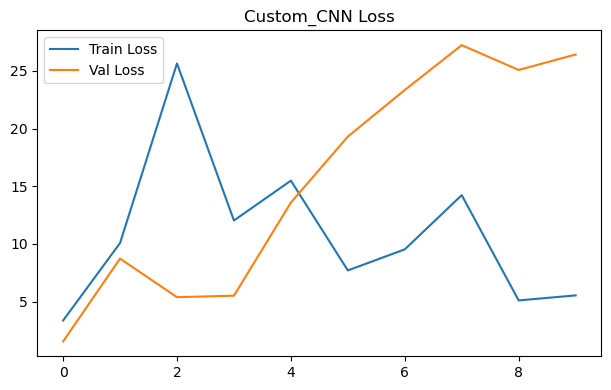

<Figure size 640x480 with 0 Axes>


▶️ Starting Training for: ResNet50_Transfer
Epoch 1/20
  Train Loss: 0.6220 Acc: 0.7917
  Val Loss: 0.5192 Acc: 0.9245
Epoch 2/20
  Train Loss: 0.5204 Acc: 0.9167
  Val Loss: 0.4592 Acc: 0.8868
Epoch 3/20
  Train Loss: 0.4418 Acc: 0.9167
  Val Loss: 0.4208 Acc: 0.8868
Epoch 4/20
  Train Loss: 0.3700 Acc: 0.9375
  Val Loss: 0.3890 Acc: 0.8868
Epoch 5/20
  Train Loss: 0.3477 Acc: 0.9167
  Val Loss: 0.3669 Acc: 0.9057
Epoch 6/20
  Train Loss: 0.2796 Acc: 0.9375
  Val Loss: 0.3513 Acc: 0.9057
🛑 Early Stopping triggered at epoch 6!

📊 ResNet50_Transfer Final Classification Report:
              precision    recall  f1-score   support

        bird       0.96      0.72      0.83        36
       drone       0.64      0.95      0.77        19

    accuracy                           0.80        55
   macro avg       0.80      0.83      0.80        55
weighted avg       0.85      0.80      0.80        55

Confusion Matrix:
[[26 10]
 [ 1 18]]


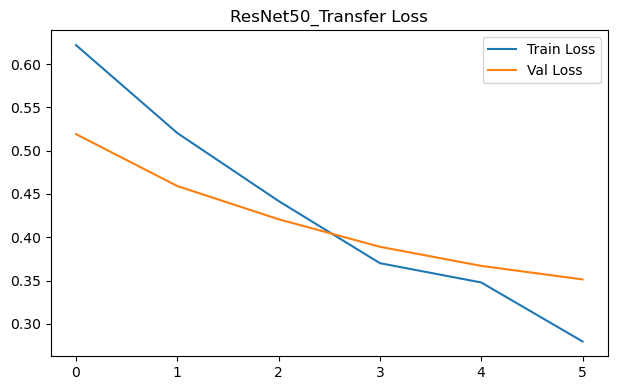

<Figure size 640x480 with 0 Axes>


🏁 FINAL MODEL COMPARISON METRICS
Metric          | Custom CNN      | ResNet50 Transfer
-----------------------------------------------------
Accuracy        | 0.6909          | 0.8000         
Precision       | 0.5294          | 0.6429         
Recall          | 0.9474          | 0.9474         
F1-Score        | 0.6792          | 0.7660         
Training Time   | 501.90       s | 418.42       s

🏆 ResNet50 Transfer outperforms Custom CNN! Saving it for Streamlit deployment.
💾 Final deployment weight model stored safely as: 'deployment_best_model.pth'


In [4]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# ========================================================
# CONFIGURATION & HYPERPARAMETERS
# ========================================================
DATA_DIR = "classification_dataset"  # Structure: dataset/train, dataset/val, dataset/test
BATCH_SIZE = 32
EPOCHS = 20
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"🚀 Using Device: {DEVICE}")

# Data Loaders (Re-using transformations from previous steps)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
}

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x]) 
                  for x in ['train', 'val', 'test'] if os.path.exists(os.path.join(DATA_DIR, x))}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x=='train'), num_workers=2) 
               for x in image_datasets.keys()}
class_names = image_datasets['train'].classes

# ========================================================
# 4. MODEL BUILDING
# ========================================================

# A. Custom CNN Model Architecture
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Out: 112x112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Out: 56x56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # Out: 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 216),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(216, num_classes)
        )
        
    def forward(self, x):
        return self.classifier(self.features(x))

# B. Transfer Learning Setup (ResNet50)
def get_resnet50_transfer(num_classes=2):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    # Freeze core backbone layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace top dense classifier head
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

# ========================================================
# 5. MODEL TRAINING (With EarlyStopping & ModelCheckpoint)
# ========================================================
def train_with_callbacks(model, model_name, criterion, optimizer, patience=5):
    print(f"\n▶️ Starting Training for: {model_name}")
    model = model.to(DEVICE)
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    epochs_no_improve = 0
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = (running_corrects.double() / len(image_datasets[phase])).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            
            print(f"  {phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # ModelCheckpoint & Early Stopping Logic
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # Checkpoint Save
                    torch.save(best_model_wts, f"{model_name}_best_checkpoint.pth")
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    
        if epochs_no_improve >= patience:
            print(f"🛑 Early Stopping triggered at epoch {epoch+1}!")
            break

    total_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    return model, history, total_time

# ========================================================
# 6. MODEL EVALUATION & PLOTTING
# ========================================================
def evaluate_and_plot(model, history, model_name):
    model.eval().to(DEVICE)
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n📊 {model_name} Final Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print(f"Confusion Matrix:\n{cm}")
    
    # Plot Learning Curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.savefig(f"{model_name}_curves.png")
    plt.close()
    plt.tight_layout()
    plt.show()
    
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1-score": f1}

# ========================================================
# 7. EXECUTION & MODEL COMPARISON
# ========================================================
if __name__ == "__main__":
    criterion = nn.CrossEntropyLoss()
    
    # Train Custom CNN
    cnn_model = CustomCNN()
    cnn_opt = optim.Adam(cnn_model.parameters(), lr=0.001)
    cnn_model, cnn_history, cnn_time = train_with_callbacks(cnn_model, "Custom_CNN", criterion, cnn_opt)
    cnn_metrics = evaluate_and_plot(cnn_model, cnn_history, "Custom_CNN")
    
    # Train Transfer Learning Model
    resnet_model = get_resnet50_transfer()
    resnet_opt = optim.Adam(resnet_model.fc.parameters(), lr=0.001)
    resnet_model, resnet_history, resnet_time = train_with_callbacks(resnet_model, "ResNet50_Transfer", criterion, resnet_opt)
    resnet_metrics = evaluate_and_plot(resnet_model, resnet_history, "ResNet50_Transfer")
    
    # Display Side-by-Side Comparison
    print("\n" + "="*50 + "\n🏁 FINAL MODEL COMPARISON METRICS\n" + "="*50)
    print(f"{'Metric':<15} | {'Custom CNN':<15} | {'ResNet50 Transfer':<15}")
    print("-" * 53)
    print(f"{'Accuracy':<15} | {cnn_metrics['accuracy']:<15.4f} | {resnet_metrics['accuracy']:<15.4f}")
    print(f"{'Precision':<15} | {cnn_metrics['precision']:<15.4f} | {resnet_metrics['precision']:<15.4f}")
    print(f"{'Recall':<15} | {cnn_metrics['recall']:<15.4f} | {resnet_metrics['recall']:<15.4f}")
    print(f"{'F1-Score':<15} | {cnn_metrics['f1-score']:<15.4f} | {resnet_metrics['f1-score']:<15.4f}")
    print(f"{'Training Time':<15} | {cnn_time:<13.2f}s | {resnet_time:<13.2f}s")
    
    # Save Best Model for Streamlit Deployment
    if resnet_metrics['accuracy'] >= cnn_metrics['accuracy']:
        print("\n🏆 ResNet50 Transfer outperforms Custom CNN! Saving it for Streamlit deployment.")
        torch.save(resnet_model.state_dict(), "deployment_best_model.pth")
    else:
        print("\n🏆 Custom CNN outperforms ResNet50 Transfer! Saving it for Streamlit deployment.")
        torch.save(cnn_model.state_dict(), "deployment_best_model.pth")
    print("💾 Final deployment weight model stored safely as: 'deployment_best_model.pth'")